In [15]:
import cv2
import matplotlib.pyplot as LePhiAn


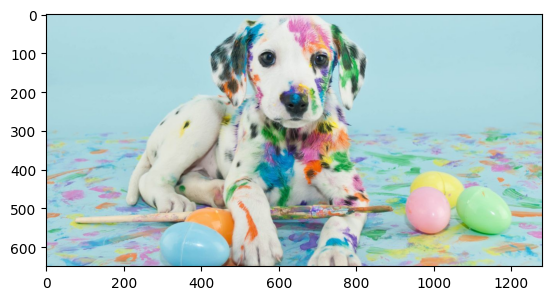

In [16]:
img = cv2.imread('../img/dog.jpg')
img = img[:,:,::-1]
LePhiAn.imshow(img)


In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as LePhiAn


In [18]:
img = cv2.imread('../img/dog.jpg',0)
img_float32 = np.float32(img)


In [19]:
dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)


In [20]:
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

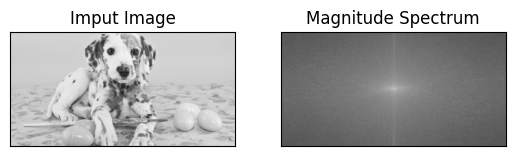

In [ ]:
LePhiAn.subplot(121), LePhiAn.imshow(img, cmap = 'gray')
LePhiAn.title('Imput Image'), LePhiAn.xticks([]), LePhiAn.yticks([])
LePhiAn.subplot(122), LePhiAn.imshow(magnitude_spectrum, cmap = 'gray')
LePhiAn.title('Magnitude Spectrum'), LePhiAn.xticks([]), LePhiAn.yticks([])
LePhiAn.show()


In [ ]:
import matplotlib.pyplot as LePhiAn
import numpy as np
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift


In [10]:
image = gravel()
wimage = image * window('hann', image.shape)  # window image to improve FFT
filtered_image = difference_of_gaussians(image, 1, 12)
filtered_wimage = filtered_image * window('hann', image.shape)
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))


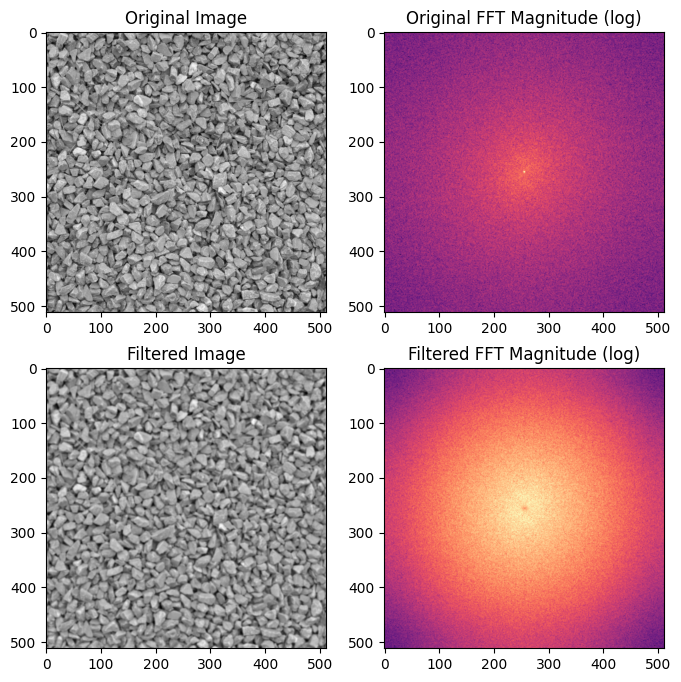

In [ ]:
fig, ax = LePhiAn.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')
LePhiAn.show()


In [ ]:
import cv2
import numpy as np
from IPython.display import Image
def detect_corner(image_path, blockSize=2, ksize=3, k=0.04, threshold=0.01):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    dst = cv2.cornerHarris(gray, blockSize, ksize, k)
    #result is dilated for marking the corners, not important
    dst = cv2.dilate(dst, None)
    # Threshold for an optimal value, it may vary depending on the image.
    img[dst>threshold*dst.max()]=[0, 0, 255]
    cv2.imwrite('example.jpg',img)
    return img
out_path = detect_corner('../img/dog.jpg', blockSize=2, ksize=5, k=0.04, threshold=0.005)
Image(out_path)


In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as LePhiAn


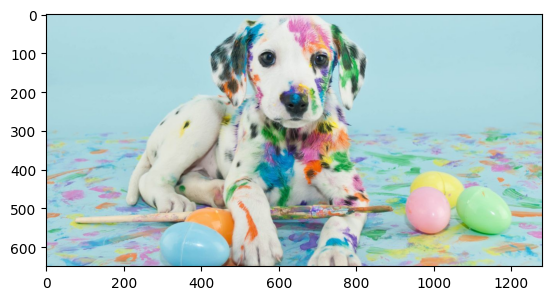

In [ ]:
img = cv2.imread('../img/dog.jpg')
LePhiAn.imshow(img[:,:,::-1])


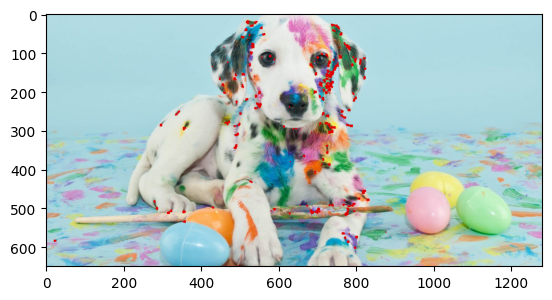

In [34]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray,2,3,0.04)
dst = cv2.dilate(dst,None)
img[dst>0.01*dst.max()] = [0,0,225]
LePhiAn.imshow(img[:,:,::-1])


In [35]:
import matplotlib.pyplot as LePhiAn
import numpy as np
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift

image = gravel()
wimage = image * window('hann', image.shape)  # window image to improve FFT
filtered_image = difference_of_gaussians(image, 1, 12)
filtered_wimage = filtered_image * window('hann', image.shape)
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))


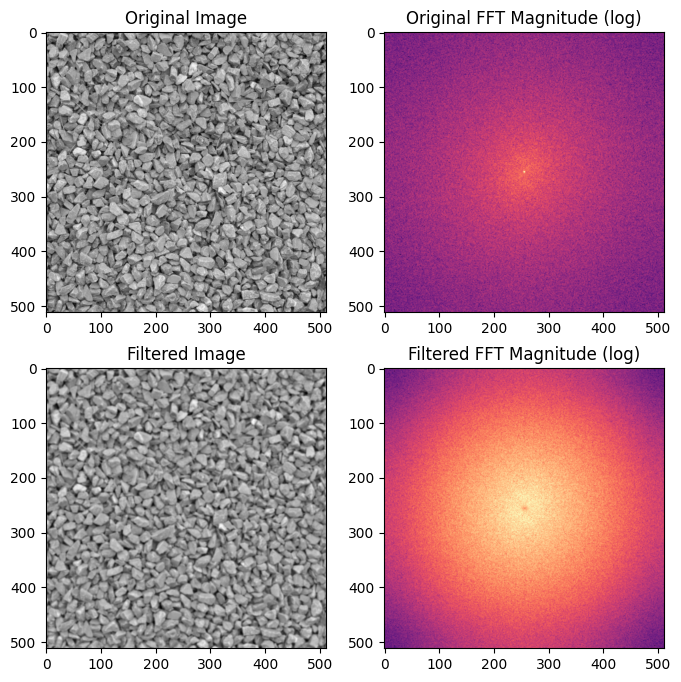

In [36]:
fig, ax = LePhiAn.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')
LePhiAn.show()
